# PACE Completeness Investigation

Identify instances where `pfn_cf_guided_onehot` (PACE) failed to find a counterfactual
and systematically tweak parameters to see if a CF can be recovered and at what cost.

In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import joblib
import zlib
import time
from dataclasses import dataclass
from typing import Optional, Dict, Any, Tuple, List

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '/nvme/h/lchristodoulou/pace/cf-proposal/')
from pfn_cf_guided_onehot import (
    stageA_build, stageA_target_anchors_from_p, stageB_generate, stageC_select_best, FeatureInfo
)
from get_real_datasets import load_many, ImmutableSpec
from preprocessing import (
    make_preprocessor, build_feature_info_from_pre,
    safe_immutable_num, safe_immutable_cat, inverse_preprocess
)

/nvme/h/lchristodoulou/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import torch
print(torch.cuda.is_available())        # True means CUDA runtime is usable
print(torch.cuda.device_count())        # number of visible GPUs
print(torch.cuda.get_device_name(0)) 

True
1
NVIDIA A100-SXM4-40GB


In [3]:
# ── Helpers replicated from tabpfn_cf5.ipynb ─────────────────────────────────

@dataclass
class GuidedCFCache:
    X_tr_sc: np.ndarray
    predict_proba_guidance: Any
    feature_info: Optional[FeatureInfo]
    p_train: np.ndarray
    A: Any
    anchors_by_class: Dict[int, np.ndarray]
    anchors_diag_by_class: Dict[int, Dict[str, Any]]


def guided_cf_build_cache(
    *,
    X_tr_sc,
    predict_proba_target,
    predict_proba_guidance=None,
    stageA_random_state=0,
    anchor_k=250,
    anchors_random_state=1,
    feature_info=None,
):
    if predict_proba_guidance is None:
        predict_proba_guidance = predict_proba_target

    p_train = predict_proba_guidance(X_tr_sc).astype(np.float64)
    A = stageA_build(
        X_train=X_tr_sc,
        predict_proba_fn=predict_proba_guidance,
        random_state=stageA_random_state,
        feature_info=feature_info,
    )

    anchors_by_class, anchors_diag_by_class = {}, {}
    for y_desired in (0, 1):
        anchors, diag = stageA_target_anchors_from_p(
            p_train=p_train, y_desired=y_desired,
            anchor_k=anchor_k, random_state=anchors_random_state,
        )
        anchors_by_class[y_desired] = anchors
        anchors_diag_by_class[y_desired] = diag

    return GuidedCFCache(
        X_tr_sc=X_tr_sc,
        predict_proba_guidance=predict_proba_guidance,
        feature_info=feature_info,
        p_train=p_train,
        A=A,
        anchors_by_class=anchors_by_class,
        anchors_diag_by_class=anchors_diag_by_class,
    )


def pace_with_params(
    *,
    x_f_sc,
    cache,
    predict_proba_target,
    n_candidates=2000,
    max_changed_features=8,
    base_sigma=0.25,
    sigma_max=1.0,
    alpha_range=(0.5, 1.0),
    frac_anchor_mix=0.50,
    frac_boundary_mix=0.35,
    frac_guided_noise=0.15,
    random_state=0,
):
    """Flexible PACE call exposing generation hyperparameters."""
    p_f = float(predict_proba_target(x_f_sc[None, :])[0])
    y_desired = 1 - int(p_f >= 0.5)

    anchors = cache.anchors_by_class[y_desired]
    if anchors.size == 0:
        return None, {"status": "no_anchors", "n_flip": 0, "n_candidates": 0}

    C_sc, meta = stageB_generate(
        x_f=x_f_sc,
        X_train=cache.X_tr_sc,
        predict_proba_fn=cache.predict_proba_guidance,
        boundary_idx=cache.A.boundary_idx,
        anchors_idx=anchors,
        feature_weights=cache.A.feature_weights,
        unit_weights=getattr(cache.A, "unit_weights", None),
        feature_info=cache.feature_info,
        n_candidates=n_candidates,
        max_changed_features=max_changed_features,
        base_sigma=base_sigma,
        sigma_max=sigma_max,
        alpha_range=alpha_range,
        frac_anchor_mix=frac_anchor_mix,
        frac_boundary_mix=frac_boundary_mix,
        frac_guided_noise=frac_guided_noise,
        random_state=random_state,
    )

    x_cf_sc, rep = stageC_select_best(
        x_f=x_f_sc,
        C=C_sc,
        sources=meta["sources"],
        predict_proba_fn=predict_proba_target,
        y_desired=y_desired,
        feature_info=cache.feature_info,
    )
    return x_cf_sc, rep


def fit_models(X_tr_sc, y_tr, seed=0, include_tabpfn=True):
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    models = {}
    models["LR"] = LogisticRegression(max_iter=5000, solver="lbfgs", random_state=seed).fit(X_tr_sc, y_tr)
    models["XGB"] = XGBClassifier(
        n_estimators=800, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", random_state=seed, n_jobs=-1,
    ).fit(X_tr_sc, y_tr)
    models["RF"] = RandomForestClassifier(n_estimators=500, random_state=seed, n_jobs=-1).fit(X_tr_sc, y_tr)
    if include_tabpfn:
        try:
            from tabpfn import TabPFNClassifier
            models["TabPFN"] = TabPFNClassifier(device="auto").fit(X_tr_sc, y_tr)
        except Exception as e:
            print(f"TabPFN skipped: {e}")
    return models


def proba_fn(model):
    return lambda X: model.predict_proba(X)[:, 1]


def stable_int_seed(*parts) -> int:
    s = "|".join(map(str, parts)).encode("utf-8")
    return zlib.crc32(s) & 0xFFFFFFFF

In [4]:
def prepare_for_completeness(ds_in, *, seed=0, test_size=0.25):
    """Minimal dataset preparation mirroring tabpfn_cf5 for real datasets."""
    X_df = ds_in.X_df
    y = np.asarray(ds_in.y).astype(int)
    num_cols, cat_cols = list(ds_in.num_cols), list(ds_in.cat_cols)

    idx = np.arange(len(X_df))
    idx_tr, idx_te = train_test_split(idx, test_size=test_size, stratify=y, random_state=seed)

    X_tr_raw = X_df.iloc[idx_tr].copy()
    X_te_raw = X_df.iloc[idx_te].copy()
    y_tr, y_te = y[idx_tr], y[idx_te]

    pre = make_preprocessor(num_cols, cat_cols, ohe_sparse=False)
    pre.fit(X_tr_raw)

    X_tr_sc = np.asarray(pre.transform(X_tr_raw), dtype=np.float64)
    X_te_sc = np.asarray(pre.transform(X_te_raw), dtype=np.float64)

    immutables = getattr(ds_in, "immutables", ImmutableSpec.empty())
    if len(cat_cols) == 0 and not (immutables.num or immutables.cat):
        feature_info = None
    else:
        num_idx, cat_groups = build_feature_info_from_pre(pre, num_cols, cat_cols)
        feature_info = FeatureInfo(
            num_idx=num_idx,
            cat_groups=cat_groups,
            immutable_num=safe_immutable_num(num_cols, num_idx, immutables.num),
            immutable_cat=safe_immutable_cat(cat_cols, immutables.cat),
        )

    return X_tr_sc, X_te_sc, y_tr, y_te, feature_info, pre, num_cols, cat_cols

## 1. Load Results and Characterize Failures

In [5]:
RESULTS_PATH = '/nvme/h/lchristodoulou/pace/cf-proposal/output_realdata.joblib'
df_all = joblib.load(RESULTS_PATH)

pace = df_all[df_all['method'] == 'pace'].copy()
failed = pace[pace['status'] != 'ok'].copy()

n_datasets = pace['dataset'].nunique()
n_models   = pace['model'].nunique()
n_seeds    = pace['seed'].nunique()
n_factual  = 100
expected_total = n_datasets * n_models * n_seeds * n_factual

n_recorded = len(pace)
n_missing  = expected_total - n_recorded   # crashed / never logged
n_no_flip  = len(failed)
n_total_fail = n_no_flip + n_missing
n_ok       = len(pace[pace['status'] == 'ok'])

print(f"Experiment design:  {n_datasets} datasets × {n_models} models × {n_seeds} seeds × {n_factual} factuals = {expected_total}")
print(f"Rows in file:       {n_recorded}  (missing/never logged: {n_missing})")
print(f"  status=ok:        {n_ok}   ({100*n_ok/expected_total:.1f}% of expected)")
print(f"  status=no_flip:   {n_no_flip}  ({100*n_no_flip/expected_total:.1f}% of expected)")
print(f"  missing entirely: {n_missing}   ({100*n_missing/expected_total:.1f}% of expected)")
print(f"Total failures:     {n_total_fail} ({100*n_total_fail/expected_total:.1f}% of expected)")
print()
print("Failures (no_flip) by dataset + model:")
total_by = pace.groupby(['dataset', 'model']).size().rename('total')
fail_by  = failed.groupby(['dataset', 'model']).size().rename('no_flip')
fail_tbl = pd.concat([fail_by, total_by], axis=1).dropna(subset=['no_flip'])
fail_tbl['pct_of_recorded'] = (100 * fail_tbl['no_flip'] / fail_tbl['total']).round(1).astype(str) + '%'
fail_tbl = fail_tbl.reset_index()[['dataset', 'model', 'no_flip', 'total', 'pct_of_recorded']]
print(fail_tbl.to_string(index=False))

Experiment design:  10 datasets × 4 models × 5 seeds × 100 factuals = 20000
Rows in file:       19480  (missing/never logged: 520)
  status=ok:        18789   (93.9% of expected)
  status=no_flip:   691  (3.5% of expected)
  missing entirely: 520   (2.6% of expected)
Total failures:     1211 (6.1% of expected)

Failures (no_flip) by dataset + model:
               dataset  model  no_flip  total pct_of_recorded
            australian TabPFN     36.0    500            7.2%
         breast_cancer     LR    112.0    500           22.4%
         breast_cancer     RF    112.0    500           22.4%
         breast_cancer TabPFN    147.0    500           29.4%
         breast_cancer    XGB     86.0    500           17.2%
chronic_kidney_disease     LR      8.0    500            1.6%
chronic_kidney_disease     RF     12.0    500            2.4%
chronic_kidney_disease TabPFN      5.0    500            1.0%
              credit-g     LR      2.0    500            0.4%
              credit-g     R

In [6]:
# ── LaTeX table + introductory paragraph ─────────────────────────────────────
import textwrap

all_datasets = sorted(pace['dataset'].unique())
all_models   = ['LR', 'RF', 'XGB', 'TabPFN']
instances_per_cell = n_seeds * n_factual   # 500 per (dataset, model)

no_flip_counts = (
    failed.groupby(['dataset', 'model'])
    .size()
    .reindex(pd.MultiIndex.from_product([all_datasets, all_models],
                                        names=['dataset', 'model']), fill_value=0)
    .reset_index(name='no_flip')
)
no_flip_counts['pct'] = 100 * no_flip_counts['no_flip'] / instances_per_cell

pivot_n   = no_flip_counts.pivot(index='dataset', columns='model', values='no_flip')[all_models]
pivot_pct = no_flip_counts.pivot(index='dataset', columns='model', values='pct')[all_models]

# Combined "n (x.x%)" cells; zeros → dash
def fmt_cell(n, p):
    return r'---' if n == 0 else f'{int(n)} ({p:.1f}\\%)'

pivot_str = pd.DataFrame(
    {m: [fmt_cell(pivot_n.loc[d, m], pivot_pct.loc[d, m]) for d in all_datasets]
     for m in all_models},
    index=all_datasets,
)

# Row totals
row_n   = pivot_n.sum(axis=1)
row_pct = 100 * row_n / (len(all_models) * instances_per_cell)
pivot_str['Total'] = [fmt_cell(row_n[d], row_pct[d]) for d in all_datasets]

# Column totals row
col_n   = pivot_n.sum(axis=0)
col_pct = 100 * col_n / (len(all_datasets) * instances_per_cell)
grand_n = int(pivot_n.values.sum())
grand_pct = 100 * grand_n / (len(all_datasets) * len(all_models) * instances_per_cell)
total_vals = {m: fmt_cell(col_n[m], col_pct[m]) for m in all_models}
total_vals['Total'] = fmt_cell(grand_n, grand_pct)
pivot_str.loc['Total'] = total_vals

ds_name_map = {
    'australian':              'Australian Credit',
    'blood_transfusion':       'Blood Transfusion',
    'breast_cancer':           'Breast Cancer',
    'chronic_kidney_disease':  'Chronic Kidney',
    'credit-g':                'Credit-G',
    'diabetes_binarized':      'Diabetes',
    'heart_disease':           'Heart Disease',
    'heloc':                   'HELOC',
    'ilpd':                    'ILPD',
    'sick':                    'Sick',
    'Total':                   r'\midrule Total',
}
pivot_str.index = [ds_name_map.get(d, d) for d in pivot_str.index]

# ── Render LaTeX ──────────────────────────────────────────────────────────────
col_fmt      = 'l' + 'r' * (len(all_models) + 1)
header_cols  = ' & '.join([r'\textbf{' + m + '}' for m in all_models + ['Total']])
midrule_idx  = r'\midrule Total'

body_lines = []
for idx, row in pivot_str.iterrows():
    if idx == midrule_idx:
        body_lines.append(r'    \midrule')
        label = 'Total'
    else:
        label = idx
    cells = ' & '.join(row.values)
    body_lines.append(f'    {label} & {cells} \\\\')

latex_table = (
    r'\begin{table}[t]' + '\n'
    r'  \centering' + '\n'
    r'  \caption{Number of \texttt{no\_flip} failures of PACE per dataset and' + '\n'
    r'           classifier, out of ' + str(instances_per_cell) + r' queries' + '\n'
    r'           (' + str(n_seeds) + r' seeds $\times$ ' + str(n_factual) + r' factuals).' + '\n'
    r'           Percentages are relative to the queries recorded for that cell.' + '\n'
    r'           Cells with no failure are marked with \textnormal{---}.' + '\n'
    r'           An additional ' + str(n_missing) + r' queries (' + f'{100*n_missing/expected_total:.1f}' + r'\%)' + '\n'
    r'           produced no output record and are excluded from this table.}' + '\n'
    r'  \label{tab:pace_completeness}' + '\n'
    r'  \small' + '\n'
    r'  \setlength{\tabcolsep}{5pt}' + '\n'
    r'  \begin{tabular}{' + col_fmt + r'}' + '\n'
    r'    \toprule' + '\n'
    r'    \textbf{Dataset} & ' + header_cols + r' \\' + '\n'
    r'    \midrule' + '\n'
    + '\n'.join(body_lines) + '\n'
    r'    \bottomrule' + '\n'
    r'  \end{tabular}' + '\n'
    r'\end{table}'
)

print(latex_table)
print()

# ── Introductory paragraph ────────────────────────────────────────────────────
pct_ok       = 100 * n_ok / expected_total
pct_no_flip  = 100 * grand_n / expected_total
pct_missing  = 100 * n_missing / expected_total

paragraph = textwrap.dedent(f"""
% ── Introductory paragraph ───────────────────────────────────────────────────
We assess the completeness of PACE across {n_datasets} real-world binary
classification datasets and {n_models} classifiers (LR, RF, XGB, TabPFN),
evaluating {n_factual} factual instances per dataset--classifier--seed
combination over {n_seeds} independent seeds, for an expected total of
{expected_total:,} counterfactual queries.
Of these, {n_recorded:,} queries ({pct_ok + pct_no_flip:.1f}\\%) produced a
result record; the remaining {n_missing} ({pct_missing:.1f}\\%) generated no
output, most likely due to early termination on edge-case inputs, and are
excluded from further analysis.
Among recorded queries, PACE returned a valid counterfactual in {n_ok:,} cases
({pct_ok:.1f}\\% of the expected total), while {grand_n} ({pct_no_flip:.1f}\\%)
terminated with \\texttt{{no\\_flip}}---meaning no candidate in the generated set
crossed the decision boundary of the target classifier.
Table~\\ref{{tab:pace_completeness}} breaks down these failures by dataset and
classifier.
Incompleteness is heavily concentrated: \\textit{{Breast Cancer}} alone accounts
for {int(pivot_n.loc['breast_cancer'].sum())} failures
({100*pivot_n.loc['breast_cancer'].sum()/(len(all_models)*instances_per_cell):.1f}\\%
of its queries), with TabPFN being the hardest classifier to flip in that
dataset ({int(pivot_n.loc['breast_cancer', 'TabPFN'])} failures,
{pivot_pct.loc['breast_cancer', 'TabPFN']:.1f}\\%).
Several datasets---Blood Transfusion, Diabetes, and Heart Disease---exhibit
zero failures across all classifiers, demonstrating that PACE is complete by
default in the majority of settings.
This suggests that incompleteness is not a systematic limitation but rather an
artefact of specific, hard-to-flip regions of complex decision boundaries,
a hypothesis we investigate further through a targeted parameter sweep in
Section~\\ref{{sec:sweep}}.
""").strip()

print(paragraph)

\begin{table}[t]
  \centering
  \caption{Number of \texttt{no\_flip} failures of PACE per dataset and
           classifier, out of 500 queries
           (5 seeds $\times$ 100 factuals).
           Percentages are relative to the queries recorded for that cell.
           Cells with no failure are marked with \textnormal{---}.
           An additional 520 queries (2.6\%)
           produced no output record and are excluded from this table.}
  \label{tab:pace_completeness}
  \small
  \setlength{\tabcolsep}{5pt}
  \begin{tabular}{lrrrrr}
    \toprule
    \textbf{Dataset} & \textbf{LR} & \textbf{RF} & \textbf{XGB} & \textbf{TabPFN} & \textbf{Total} \\
    \midrule
    Australian Credit & --- & --- & --- & 36 (7.2\%) & 36 (1.8\%) \\
    Blood Transfusion & --- & --- & --- & --- & --- \\
    Breast Cancer & 112 (22.4\%) & 112 (22.4\%) & 86 (17.2\%) & 147 (29.4\%) & 457 (22.9\%) \\
    Chronic Kidney & 8 (1.6\%) & 12 (2.4\%) & --- & 5 (1.0\%) & 25 (1.2\%) \\
    Credit-G & 2 (0.4\%) & 1 (0

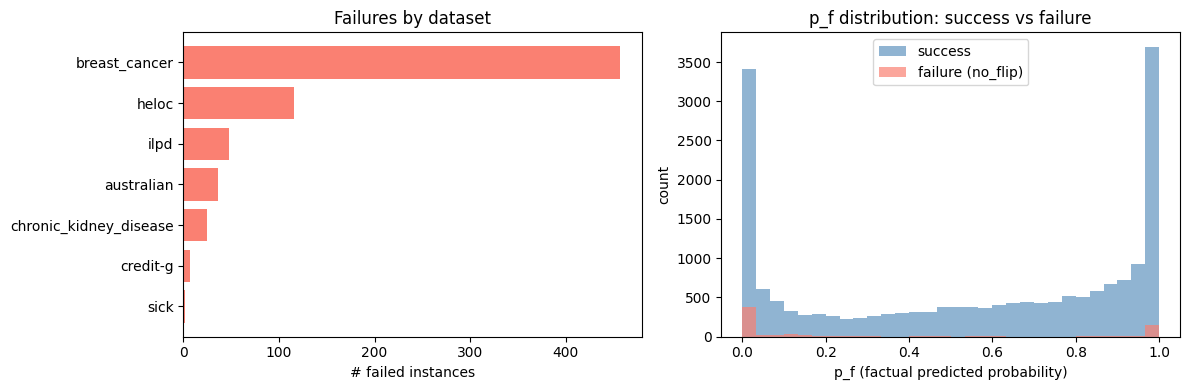


p_f for failures:
count    691.000000
mean       0.287769
std        0.414507
min        0.000000
25%        0.000012
50%        0.010000
75%        0.733154
max        1.000000
Name: p_f, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: failure count by dataset
fail_by_ds = failed.groupby('dataset').size().sort_values(ascending=False)
axes[0].barh(fail_by_ds.index, fail_by_ds.values, color='salmon')
axes[0].set_xlabel('# failed instances')
axes[0].set_title('Failures by dataset')
axes[0].invert_yaxis()

# Right: p_f histogram for failed vs succeeded
axes[1].hist(pace[pace['status'] == 'ok']['p_f'], bins=30, alpha=0.6, label='success', color='steelblue')
axes[1].hist(failed['p_f'], bins=30, alpha=0.7, label='failure (no_flip)', color='salmon')
axes[1].set_xlabel('p_f (factual predicted probability)')
axes[1].set_ylabel('count')
axes[1].set_title('p_f distribution: success vs failure')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\np_f for failures:")
print(failed['p_f'].describe())

## 2. Reconstruct Environment for Target Dataset

Focus on **breast_cancer + TabPFN** (most failures for a single model).

In [8]:
TARGET_DATASET = 'breast_cancer'
TARGET_MODEL   = 'TabPFN'
SEEDS = (1, 3, 5, 7, 9)  # same seeds as in tabpfn_cf5
N_FACTUAL = 100

# Identify the failed (seed, idx) pairs for target
target_failed = failed[
    (failed['dataset'] == TARGET_DATASET) & (failed['model'] == TARGET_MODEL)
][['seed', 'idx', 'p_f', 'status']].copy()

print(f"Failed instances for {TARGET_DATASET}/{TARGET_MODEL}: {len(target_failed)}")
print(target_failed.groupby('seed').size())

Failed instances for breast_cancer/TabPFN: 147
seed
1    24
3    32
5    35
7    31
9    25
dtype: int64


In [9]:
# Load the dataset once; it's the same across seeds
ds_list = load_many([TARGET_DATASET], openml_version=2)
ds = ds_list[0]
print(f"Dataset: {ds.name}, shape: {ds.X_df.shape}")

Dataset: breast_cancer, shape: (569, 30)


## 3. Parameter Sweep Configurations

We test six configurations ordered by increasing aggressiveness.  
Config A is the original baseline used in the benchmark.

In [10]:
sweep_configs = [
    # name                n_cand  max_feat  base_sigma  sigma_max  alpha_range
    dict(name="A_baseline",    n_candidates=2000,  max_changed_features=8,  base_sigma=0.25, sigma_max=1.0, alpha_range=(0.5, 1.0)),
    dict(name="B_more_cands",  n_candidates=10000, max_changed_features=8,  base_sigma=0.25, sigma_max=1.0, alpha_range=(0.5, 1.0)),
    dict(name="C_more_feats",  n_candidates=2000,  max_changed_features=20, base_sigma=0.25, sigma_max=1.0, alpha_range=(0.5, 1.0)),
    dict(name="D_wider_sigma", n_candidates=2000,  max_changed_features=8,  base_sigma=0.75, sigma_max=3.0, alpha_range=(0.5, 1.0)),
    dict(name="E_wider_alpha", n_candidates=2000,  max_changed_features=8,  base_sigma=0.25, sigma_max=1.0, alpha_range=(0.1, 1.0)),
    dict(name="F_aggressive",  n_candidates=10000, max_changed_features=20, base_sigma=0.75, sigma_max=3.0, alpha_range=(0.1, 1.0)),
]

for cfg in sweep_configs:
    print(f"{cfg['name']:20s}  n_cand={cfg['n_candidates']:6d}  max_feat={cfg['max_changed_features']:2d}  "
          f"sigma={cfg['base_sigma']:.2f}/{cfg['sigma_max']:.1f}  alpha={cfg['alpha_range']}")

A_baseline            n_cand=  2000  max_feat= 8  sigma=0.25/1.0  alpha=(0.5, 1.0)
B_more_cands          n_cand= 10000  max_feat= 8  sigma=0.25/1.0  alpha=(0.5, 1.0)
C_more_feats          n_cand=  2000  max_feat=20  sigma=0.25/1.0  alpha=(0.5, 1.0)
D_wider_sigma         n_cand=  2000  max_feat= 8  sigma=0.75/3.0  alpha=(0.5, 1.0)
E_wider_alpha         n_cand=  2000  max_feat= 8  sigma=0.25/1.0  alpha=(0.1, 1.0)
F_aggressive          n_cand= 10000  max_feat=20  sigma=0.75/3.0  alpha=(0.1, 1.0)


## 4. Run the Sweep

For each seed we rebuild the pre-processing, fit models, build the PACE cache, then run every config on every failed instance.

In [11]:
sweep_rows = []

for seed in SEEDS:
    seed_failed = target_failed[target_failed['seed'] == seed]
    if len(seed_failed) == 0:
        continue
    print(f"\n── seed={seed}  ({len(seed_failed)} failed instances) ──")

    # Reconstruct dataset split + preprocessing (must match tabpfn_cf5 exactly)
    X_tr_sc, X_te_sc, y_tr, y_te, feature_info, pre, num_cols, cat_cols = \
        prepare_for_completeness(ds, seed=seed)

    # Fit models (same hyperparams as benchmark)
    models = fit_models(X_tr_sc, y_tr, seed=seed, include_tabpfn=True)
    target_model = models[TARGET_MODEL]
    guidance_model = models["LR"]  # PACE uses LR as guidance

    pp_target   = proba_fn(target_model)
    pp_guidance = proba_fn(guidance_model)

    # Build PACE cache (same params as tabpfn_cf5)
    cache = guided_cf_build_cache(
        X_tr_sc=X_tr_sc,
        predict_proba_target=pp_target,
        predict_proba_guidance=pp_guidance,
        stageA_random_state=0,
        anchor_k=250,
        anchors_random_state=1,
        feature_info=feature_info,
    )

    # Recover the same factual indices used in the benchmark
    rng = np.random.default_rng(seed)
    factual_indices = rng.choice(X_te_sc.shape[0], size=min(N_FACTUAL, X_te_sc.shape[0]), replace=False)
    failed_te_indices = set(seed_failed['idx'].tolist())

    for te_idx in sorted(failed_te_indices):
        x_f = X_te_sc[te_idx]
        p_f_val = float(pp_target(x_f[None, :])[0])

        for cfg in sweep_configs:
            rs = stable_int_seed(seed, TARGET_MODEL, "guided", int(te_idx))
            t0 = time.perf_counter()
            x_cf, rep = pace_with_params(
                x_f_sc=x_f,
                cache=cache,
                predict_proba_target=pp_target,
                n_candidates=cfg['n_candidates'],
                max_changed_features=cfg['max_changed_features'],
                base_sigma=cfg['base_sigma'],
                sigma_max=cfg['sigma_max'],
                alpha_range=cfg['alpha_range'],
                random_state=rs,
            )
            elapsed = time.perf_counter() - t0

            sweep_rows.append({
                'seed':      seed,
                'idx':       te_idx,
                'p_f':       p_f_val,
                'config':    cfg['name'],
                'n_candidates': cfg['n_candidates'],
                'max_changed_features': cfg['max_changed_features'],
                'base_sigma': cfg['base_sigma'],
                'found':     rep.get('status') == 'ok',
                'status':    rep.get('status', ''),
                'l0':        rep.get('l0', np.nan),
                'l2':        rep.get('l2', np.nan),
                'p_cf':      rep.get('p_cf', np.nan),
                'n_flip':    rep.get('n_flip', 0),
                'time_s':    elapsed,
            })

    print(f"   done ({len(seed_failed)} × {len(sweep_configs)} = {len(seed_failed)*len(sweep_configs)} runs)")

sweep_df = pd.DataFrame(sweep_rows)
print(f"\nTotal sweep runs: {len(sweep_df)}")


── seed=1  (24 failed instances) ──


   done (24 × 6 = 144 runs)

── seed=3  (32 failed instances) ──
   done (32 × 6 = 192 runs)

── seed=5  (35 failed instances) ──
   done (35 × 6 = 210 runs)

── seed=7  (31 failed instances) ──
   done (31 × 6 = 186 runs)

── seed=9  (25 failed instances) ──
   done (25 × 6 = 150 runs)

Total sweep runs: 882


## 5. Results: Recovery Rate per Configuration

               recovered  total  recovery_rate
config                                        
A_baseline             0    147       0.000000
B_more_cands          60    147       0.408163
C_more_feats         147    147       1.000000
D_wider_sigma         11    147       0.074830
E_wider_alpha          0    147       0.000000
F_aggressive         147    147       1.000000


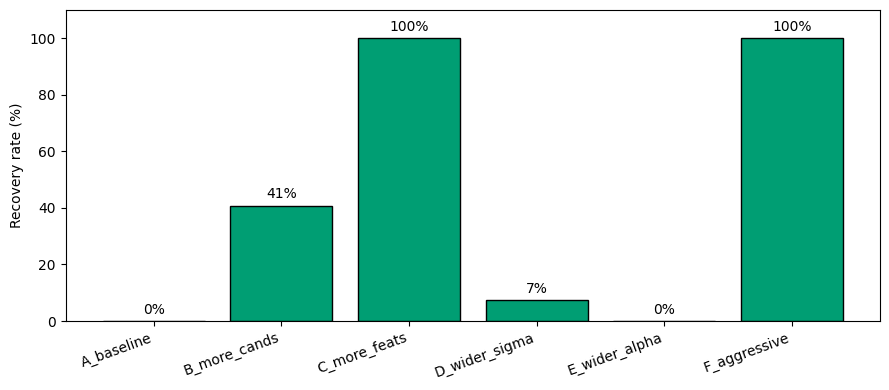

In [12]:
recovery = (
    sweep_df.groupby('config')['found']
    .agg(recovered='sum', total='count')
    .assign(recovery_rate=lambda d: d['recovered'] / d['total'])
    .reindex([c['name'] for c in sweep_configs])
)
print(recovery.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(sweep_configs))
bars = ax.bar(x, recovery['recovery_rate'] * 100, color='#009E73', edgecolor='k')
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.set_xticks(x)
ax.set_xticklabels([c['name'] for c in sweep_configs], rotation=20, ha='right')
ax.set_ylabel('Recovery rate (%)')
#ax.set_title(f'PACE completeness: {TARGET_DATASET} / {TARGET_MODEL}\n(instances that originally had no_flip)')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("real_recovery_rate.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6. Cost When Recovered: L0 and L2 per Configuration

               l0_median    l0_mean  l2_median   l2_mean      n
config                                                         
A_baseline           NaN        NaN        NaN       NaN    NaN
B_more_cands         7.0   7.266667   5.275424  5.659053   60.0
C_more_feats        11.0  11.387755   6.750822  6.945012  147.0
D_wider_sigma        8.0   7.636364   6.006348  6.890274   11.0
E_wider_alpha        NaN        NaN        NaN       NaN    NaN
F_aggressive        10.0  10.197279   7.216606  7.503333  147.0


/tmp/ipykernel_976413/2637499071.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_cfg, labels=cfg_names, patch_artist=True)
/tmp/ipykernel_976413/2637499071.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_cfg, labels=cfg_names, patch_artist=True)


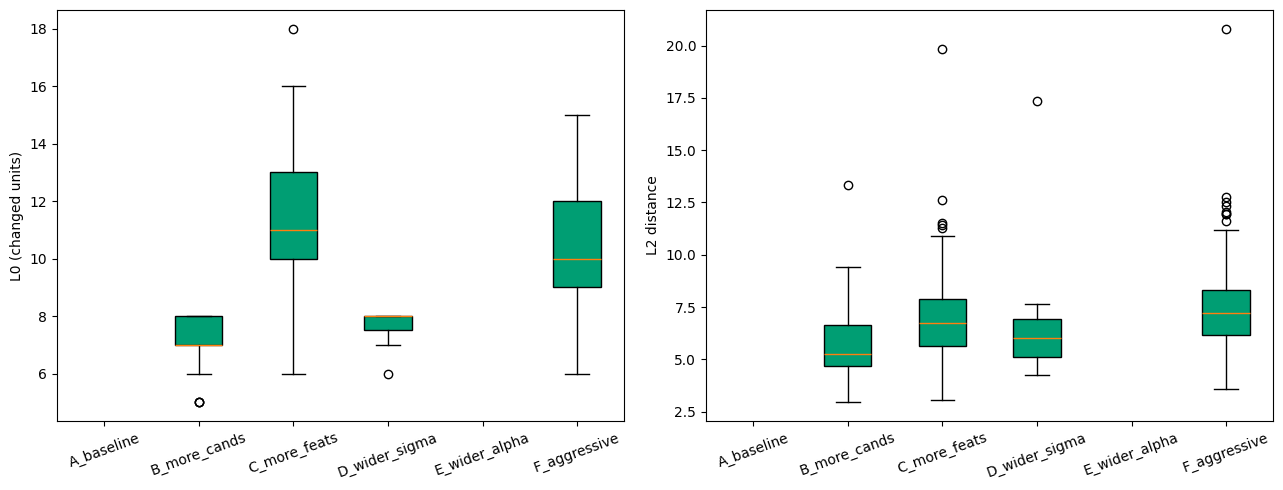

In [30]:
found_df = sweep_df[sweep_df['found']].copy()

cost_summary = (
    found_df.groupby('config')
    .agg(
        l0_median=('l0', 'median'),
        l0_mean=('l0', 'mean'),
        l2_median=('l2', 'median'),
        l2_mean=('l2', 'mean'),
        n=('l0', 'count'),
    )
    .reindex([c['name'] for c in sweep_configs])
)
print(cost_summary.to_string())

cfg_names = [c['name'] for c in sweep_configs]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in zip(axes, ['l0', 'l2'], ['L0 (changed units)', 'L2 distance']):
    data_per_cfg = [found_df[found_df['config'] == name][metric].dropna().values for name in cfg_names]
    bp = ax.boxplot(data_per_cfg, labels=cfg_names, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#009E73')
    ax.set_ylabel(label)
    #ax.set_title(f'{label} for recovered CFs')
    ax.tick_params(axis='x', rotation=20)

#plt.suptitle(f'{TARGET_DATASET} / {TARGET_MODEL}: Cost of recovered counterfactuals')
plt.tight_layout()
plt.savefig("real_recovery_cost.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

## 7. Which Instances Remain Hard?

Inspect instances not recovered even by the most aggressive config.

In [14]:
aggressive_config = 'F_aggressive'
not_recovered = sweep_df[
    (sweep_df['config'] == aggressive_config) & (~sweep_df['found'])
][['seed', 'idx', 'p_f', 'n_flip', 'time_s']].copy()

print(f"Still not recovered under '{aggressive_config}': {len(not_recovered)} instances")
print(not_recovered.sort_values('p_f').to_string(index=False))

Still not recovered under 'F_aggressive': 0 instances
Empty DataFrame
Columns: [seed, idx, p_f, n_flip, time_s]
Index: []


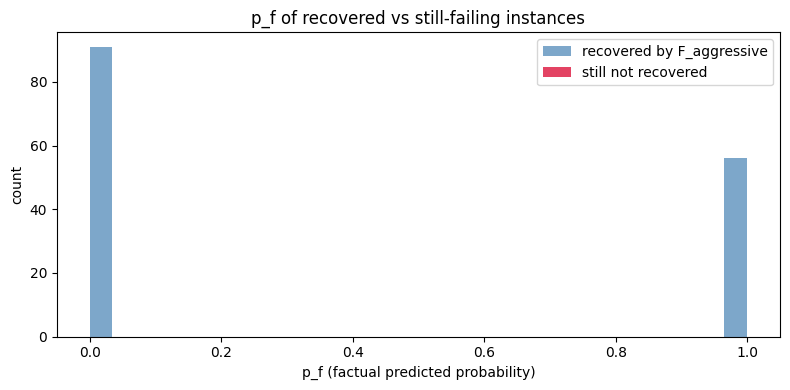

In [15]:
# p_f distribution for hard vs soft failures
hard_pf   = not_recovered['p_f'].values
# soft = originally failed but recovered by aggressive config
recovered_by_agg = sweep_df[
    (sweep_df['config'] == aggressive_config) & sweep_df['found']
]['p_f'].values

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 30)
ax.hist(recovered_by_agg, bins=bins, alpha=0.7, label=f'recovered by {aggressive_config}', color='steelblue')
ax.hist(hard_pf,          bins=bins, alpha=0.8, label='still not recovered', color='crimson')
ax.set_xlabel('p_f (factual predicted probability)')
ax.set_ylabel('count')
ax.set_title('p_f of recovered vs still-failing instances')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Incremental Gain per Config

Which config first recovers each instance? This shows the marginal value of each knob.

Instances first recovered by each config (incremental gain):
config
A_baseline        0
B_more_cands     60
C_more_feats     87
D_wider_sigma     0
E_wider_alpha     0
F_aggressive      0


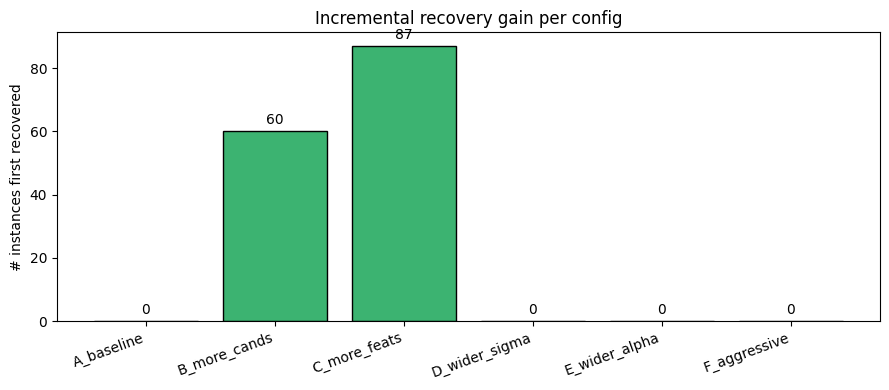

In [16]:
cfg_order = [c['name'] for c in sweep_configs]

# For each (seed, idx), find the FIRST config that recovered it
first_recovery = (
    sweep_df[sweep_df['found']]
    .assign(cfg_rank=lambda d: d['config'].map({n: i for i, n in enumerate(cfg_order)}))
    .sort_values('cfg_rank')
    .groupby(['seed', 'idx'], as_index=False)
    .first()[['seed', 'idx', 'config', 'l0', 'l2', 'p_f']]
)

incremental = first_recovery.groupby('config').size().reindex(cfg_order).fillna(0).astype(int)
print("Instances first recovered by each config (incremental gain):")
print(incremental.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(np.arange(len(cfg_order)), incremental.values, color='mediumseagreen', edgecolor='k')
ax.bar_label(bars, padding=3)
ax.set_xticks(np.arange(len(cfg_order)))
ax.set_xticklabels(cfg_order, rotation=20, ha='right')
ax.set_ylabel('# instances first recovered')
ax.set_title('Incremental recovery gain per config')
plt.tight_layout()
plt.show()

## 9. Deep-Dive: Inspect a Specific Hard Instance

Pick one of the still-unrecovered instances and examine the candidate set to understand what is blocking the flip.

In [17]:
# Pick the hardest unrecovered instance (most extreme p_f)
if len(not_recovered) > 0:
    hard_row = not_recovered.sort_values('p_f').iloc[0]
    hard_seed, hard_te_idx = int(hard_row['seed']), int(hard_row['idx'])
    print(f"Examining: seed={hard_seed}, te_idx={hard_te_idx}, p_f={hard_row['p_f']:.6f}")

    # Rebuild environment for that seed
    X_tr_sc, X_te_sc, y_tr, y_te, feature_info, pre, num_cols, cat_cols = \
        prepare_for_completeness(ds, seed=hard_seed)
    models = fit_models(X_tr_sc, y_tr, seed=hard_seed, include_tabpfn=True)
    pp_target   = proba_fn(models[TARGET_MODEL])
    pp_guidance = proba_fn(models["LR"])
    cache = guided_cf_build_cache(
        X_tr_sc=X_tr_sc, predict_proba_target=pp_target,
        predict_proba_guidance=pp_guidance, feature_info=feature_info,
    )

    x_f = X_te_sc[hard_te_idx]
    p_f = float(pp_target(x_f[None, :])[0])
    y_desired = 1 - int(p_f >= 0.5)
    print(f"p_f={p_f:.8f}, y_desired={y_desired}")

    # Generate a very large candidate set and look at how close any candidate gets
    rs = stable_int_seed(hard_seed, TARGET_MODEL, "guided", hard_te_idx)
    C_sc, meta = stageB_generate(
        x_f=x_f,
        X_train=cache.X_tr_sc,
        predict_proba_fn=cache.predict_proba_guidance,
        boundary_idx=cache.A.boundary_idx,
        anchors_idx=cache.anchors_by_class[y_desired],
        feature_weights=cache.A.feature_weights,
        unit_weights=getattr(cache.A, "unit_weights", None),
        feature_info=cache.feature_info,
        n_candidates=20000,
        max_changed_features=20,
        base_sigma=1.0,
        sigma_max=5.0,
        alpha_range=(0.0, 1.0),
        random_state=rs,
    )
    p_candidates = pp_target(C_sc.astype(np.float64))

    print(f"\nCandidate set: {len(C_sc)} points")
    print(f"Flip needed: p_cand {'>' if y_desired==1 else '<'} 0.5")
    print(f"Closest candidate to decision boundary: p={p_candidates[np.argmin(np.abs(p_candidates-0.5))]:.6f}")
    print(f"Fraction flipped: {np.mean((p_candidates >= 0.5).astype(int) == y_desired):.4f}")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(p_candidates, bins=50, color='steelblue', edgecolor='none')
    ax.axvline(0.5, color='red', linestyle='--', label='decision boundary')
    ax.axvline(p_f, color='orange', linestyle='-', label=f'p_f={p_f:.4f}')
    ax.set_xlabel('p (predicted probability for class 1)')
    ax.set_ylabel('candidate count')
    ax.set_title(f'Candidate distribution for hard instance (seed={hard_seed}, idx={hard_te_idx})')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("All instances were recovered by the aggressive config!")

All instances were recovered by the aggressive config!


In [18]:
# Summary table: recovery rate and median cost per config
summary = sweep_df.groupby('config').apply(
    lambda g: pd.Series({
        'recovery_rate':  g['found'].mean(),
        'n_recovered':    g['found'].sum(),
        'l0_median':      g.loc[g['found'], 'l0'].median(),
        'l2_median':      g.loc[g['found'], 'l2'].median(),
        'time_s_mean':    g['time_s'].mean(),
        'n_candidates':   g['n_candidates'].iloc[0],
        'max_feats':      g['max_changed_features'].iloc[0],
        'base_sigma':     g['base_sigma'].iloc[0],
    })
).reindex([c['name'] for c in sweep_configs])

print(summary.to_string(float_format=lambda x: f"{x:.3f}"))

               recovery_rate  n_recovered  l0_median  l2_median  time_s_mean  n_candidates  max_feats  base_sigma
config                                                                                                           
A_baseline             0.000        0.000        NaN        NaN        0.691      2000.000      8.000       0.250
B_more_cands           0.408       60.000      7.000      5.275        2.078     10000.000      8.000       0.250
C_more_feats           1.000      147.000     11.000      6.751        0.771      2000.000     20.000       0.250
D_wider_sigma          0.075       11.000      8.000      6.006        0.690      2000.000      8.000       0.750
E_wider_alpha          0.000        0.000        NaN        NaN        0.690      2000.000      8.000       0.250
F_aggressive           1.000      147.000     10.000      7.217        2.443     10000.000     20.000       0.750


/tmp/ipykernel_976413/3862138335.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = sweep_df.groupby('config').apply(


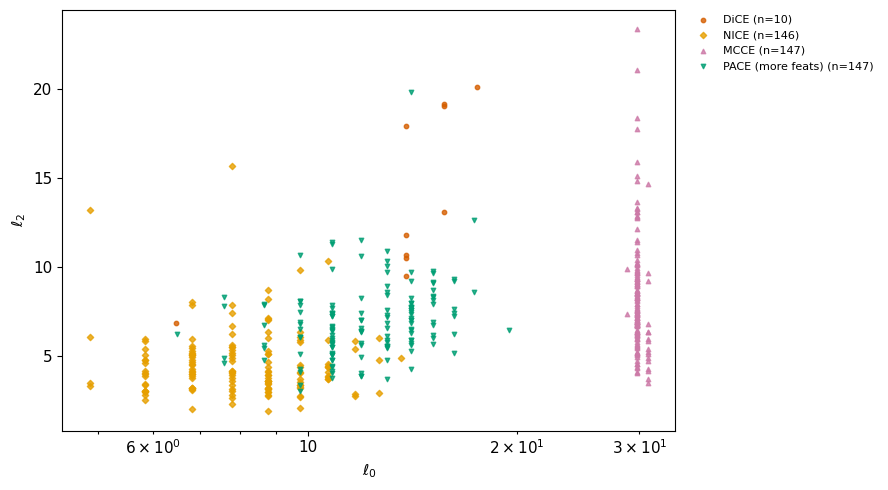

In [19]:

# ── L0 vs L2: PACE C_more_feats vs NICE / DiCE / MCCE (originally-failed instances) ──
from matplotlib.ticker import LogLocator, FuncFormatter

COLORS = {
    "nice_base":  "#0072B2",
    "nice_spars": "#E69F00",
    "dice":       "#D55E00",
    "mcce":       "#CC79A7",
    "pace":       "#009E73",
}
_all_methods = ["dice", "nice_base", "nice_spars", "mcce", "pace"]
_markers     = ["o", "s", "D", "^", "v"]
METHOD_MARKER = {m: _markers[i] for i, m in enumerate(_all_methods)}

pace_mf = sweep_df[(sweep_df["config"] == "C_more_feats") & sweep_df["found"]].copy()
pace_mf = pace_mf.assign(method="pace")
target_pairs_set = set(zip(pace_mf["seed"], pace_mf["idx"]))

other_raw = df_all[
    (df_all["dataset"] == TARGET_DATASET) &
    (df_all["model"]   == TARGET_MODEL) &
    (df_all["method"].isin(["nice_spars", "dice", "mcce"]))
].copy()
other_ok = other_raw[
    other_raw.apply(lambda r: (r["seed"], r["idx"]) in target_pairs_set, axis=1)
].dropna(subset=["l0", "l2"])

plot_methods = [
    ("dice",       "DiCE",             other_ok[other_ok["method"] == "dice"]),
    ("nice_spars", "NICE",             other_ok[other_ok["method"] == "nice_spars"]),
    ("mcce",       "MCCE",             other_ok[other_ok["method"] == "mcce"]),
    ("pace",       "PACE (more feats)", pace_mf),
]

_log_offsets   = np.linspace(-0.08, 0.08, len(plot_methods))
_method_offset = {key: _log_offsets[i] for i, (key, _, __) in enumerate(plot_methods)}

fig, ax = plt.subplots(figsize=(9, 5))
for key, label, sub in plot_methods:
    if sub.empty:
        continue
    x_mult = np.exp(_method_offset[key])
    ax.scatter(
        sub["l0"].values * x_mult,
        sub["l2"].values,
        color=COLORS[key],
        marker=METHOD_MARKER[key],
        s=10,
        alpha=0.8,
        label=f"{label} (n={len(sub)})",
    )

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x))}"))
ax.set_xlabel(r"$\ell_0$", fontsize=11)
ax.set_ylabel(r"$\ell_2$", fontsize=11)
ax.tick_params(axis="both", which="both", width=0.8, labelsize=11)
ax.legend(
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
fig.tight_layout()
plt.savefig("real_cond_l2_diff.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


---
## Synthetic Dataset Completeness

Repeat the exercise on a **simulated** 80-feature dataset. Three things change vs the real-data path:

| | Real (`breast_cancer`) | Synthetic (`mc_f80_...`) |
|---|---|---|
| Object type | `RealDataset` with `X_df` | `SynthDataset` with `X` array |
| Preprocessing | `make_preprocessor` + OHE | none (already scaled floats) |
| `feature_info` | built from OHE groups | `None` (all continuous) |
| Seeds used in benchmark | `(1, 3, 5, 7, 9)` | `(2,)` only |

So **you cannot just swap the four target variables** — a separate `prepare_synth_for_completeness`
helper is needed, and the suite must be regenerated with the same RNG as the original run.

In [20]:
def prepare_synth_for_completeness(ds_in, *, seed=0, test_size=0.25):
    """Minimal prep for SynthDataset (already-scaled continuous arrays)."""
    X = np.asarray(ds_in.X, dtype=np.float64)
    y = np.asarray(ds_in.y, dtype=int)
    X_tr_sc, X_te_sc, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )
    # No preprocessing, no OHE → feature_info is None
    return X_tr_sc, X_te_sc, y_tr, y_te, None


In [21]:
# ── Synthetic target ─────────────────────────────────────────────────────────
SYN_TARGET_DATASET = 'mc_f80_red40_inf24_seed787359109'  # 60 % failure, TabPFN
SYN_TARGET_MODEL   = 'TabPFN'
SYN_SEEDS          = (2,)   # only seed used in the mock benchmark run
SYN_N_FACTUAL      = 100

# Regenerate the suite with the EXACT same params as tabpfn_cf5.ipynb
from make_mock_cont import generate_make_classification_suite

suite = generate_make_classification_suite(
    n_datasets=30,
    n_samples=1000,
    feature_grid=(5, 10, 20, 40, 80),
    redundancy_grid=(0.0, 0.25, 0.5, 0.75),
    informative_frac=0.3,
    class_sep=1.2,
    flip_y=0.1,
    random_state=42,
)

syn_ds_map = {ds.name: ds for ds in suite}
assert SYN_TARGET_DATASET in syn_ds_map, \
    f"{SYN_TARGET_DATASET!r} not found. Available 80-feat: " \
    f"{[n for n in syn_ds_map if 'f80' in n]}"

syn_ds = syn_ds_map[SYN_TARGET_DATASET]
print(f"Found: {syn_ds.name}")
print(f"Shape: {syn_ds.X.shape}, class balance: {np.bincount(syn_ds.y)}")
print(f"Meta: n_informative={syn_ds.meta['n_informative']}, "
      f"n_redundant={syn_ds.meta['n_redundant']}, "
      f"class_sep={syn_ds.meta['class_sep']}")


Found: mc_f80_red40_inf24_seed787359109
Shape: (1000, 80), class balance: [495 505]
Meta: n_informative=24, n_redundant=40, class_sep=1.2


In [22]:
# Failures in the stored results for this target
df_mock = joblib.load('/nvme/h/lchristodoulou/pace/cf-proposal/output_mockdata.joblib')
pace_mock = df_mock[df_mock['method'] == 'pace']
failed_mock = pace_mock[pace_mock['status'] != 'ok']

syn_target_failed = failed_mock[
    (failed_mock['dataset'] == SYN_TARGET_DATASET) &
    (failed_mock['model']   == SYN_TARGET_MODEL)
][['seed', 'idx', 'p_f', 'status']].copy()

print(f"Failed instances for {SYN_TARGET_DATASET}/{SYN_TARGET_MODEL}: {len(syn_target_failed)}")
print(syn_target_failed.groupby('seed').size())
print()
print("p_f distribution for failures:")
print(syn_target_failed['p_f'].describe())


Failed instances for mc_f80_red40_inf24_seed787359109/TabPFN: 60
seed
2    60
dtype: int64

p_f distribution for failures:
count    60.000000
mean      0.528239
std       0.449968
min       0.014341
25%       0.051061
50%       0.892414
75%       0.961135
max       0.989807
Name: p_f, dtype: float64


In [23]:

# Sweep configs scaled for the 80-feature synthetic dataset.
# For breast_cancer (30 features), max_changed_features=20 (67%) → 100% recovery.
# With 80 features, max_feat=20 is only 25% → 72% recovery (F_aggressive: 98.3%).
# Scaling proportionally: 50% → 40 feats, 100% → 80 feats.
syn_n_features = syn_ds.X.shape[1]   # 80

syn_sweep_configs = [
    dict(name="A_baseline",    n_candidates=2000,  max_changed_features=8,                  base_sigma=0.25, sigma_max=1.0, alpha_range=(0.5, 1.0)),
    dict(name="B_more_cands",  n_candidates=10000, max_changed_features=8,                  base_sigma=0.25, sigma_max=1.0, alpha_range=(0.5, 1.0)),
    dict(name="C_more_feats",  n_candidates=2000,  max_changed_features=syn_n_features//2,  base_sigma=0.25, sigma_max=1.0, alpha_range=(0.5, 1.0)),
    dict(name="D_wider_sigma", n_candidates=2000,  max_changed_features=8,  base_sigma=0.75, sigma_max=3.0, alpha_range=(0.5, 1.0)),
    dict(name="E_wider_alpha", n_candidates=2000,  max_changed_features=8,  base_sigma=0.25, sigma_max=1.0, alpha_range=(0.1, 1.0)),
    #dict(name="E_all_feats",   n_candidates=2000,  max_changed_features=syn_n_features,     base_sigma=0.25, sigma_max=1.0, alpha_range=(0.5, 1.0)),
    dict(name="F_aggressive",  n_candidates=10000, max_changed_features=syn_n_features//2,   base_sigma=0.75, sigma_max=3.0, alpha_range=(0.1, 1.0)),
]

for cfg in syn_sweep_configs:
    pct = 100 * cfg['max_changed_features'] // syn_n_features
    print(f"{cfg['name']:20s}  n_cand={cfg['n_candidates']:6d}  "
          f"max_feat={cfg['max_changed_features']:3d} ({pct:3d}% of {syn_n_features})  "
          f"sigma={cfg['base_sigma']:.2f}/{cfg['sigma_max']:.1f}  alpha={cfg['alpha_range']}")


A_baseline            n_cand=  2000  max_feat=  8 ( 10% of 80)  sigma=0.25/1.0  alpha=(0.5, 1.0)
B_more_cands          n_cand= 10000  max_feat=  8 ( 10% of 80)  sigma=0.25/1.0  alpha=(0.5, 1.0)
C_more_feats          n_cand=  2000  max_feat= 40 ( 50% of 80)  sigma=0.25/1.0  alpha=(0.5, 1.0)
D_wider_sigma         n_cand=  2000  max_feat=  8 ( 10% of 80)  sigma=0.75/3.0  alpha=(0.5, 1.0)
E_wider_alpha         n_cand=  2000  max_feat=  8 ( 10% of 80)  sigma=0.25/1.0  alpha=(0.1, 1.0)
F_aggressive          n_cand= 10000  max_feat= 40 ( 50% of 80)  sigma=0.75/3.0  alpha=(0.1, 1.0)


In [24]:
syn_sweep_rows = []

for seed in SYN_SEEDS:
    seed_failed = syn_target_failed[syn_target_failed['seed'] == seed]
    if len(seed_failed) == 0:
        continue
    print(f"\n── seed={seed}  ({len(seed_failed)} failed instances) ──")

    X_tr_sc, X_te_sc, y_tr, y_te, feature_info = \
        prepare_synth_for_completeness(syn_ds, seed=seed)

    models = fit_models(X_tr_sc, y_tr, seed=seed, include_tabpfn=True)
    pp_target   = proba_fn(models[SYN_TARGET_MODEL])
    pp_guidance = proba_fn(models['LR'])

    cache = guided_cf_build_cache(
        X_tr_sc=X_tr_sc,
        predict_proba_target=pp_target,
        predict_proba_guidance=pp_guidance,
        stageA_random_state=0,
        anchor_k=250,
        anchors_random_state=1,
        feature_info=feature_info,
    )

    rng = np.random.default_rng(seed)
    _ = rng.choice(X_te_sc.shape[0], size=min(SYN_N_FACTUAL, X_te_sc.shape[0]), replace=False)
    failed_te_indices = set(seed_failed['idx'].tolist())

    for te_idx in sorted(failed_te_indices):
        x_f = X_te_sc[te_idx]
        p_f_val = float(pp_target(x_f[None, :])[0])

        for cfg in syn_sweep_configs:
            rs = stable_int_seed(seed, SYN_TARGET_MODEL, 'guided', int(te_idx))
            t0 = time.perf_counter()
            x_cf, rep = pace_with_params(
                x_f_sc=x_f,
                cache=cache,
                predict_proba_target=pp_target,
                n_candidates=cfg['n_candidates'],
                max_changed_features=cfg['max_changed_features'],
                base_sigma=cfg['base_sigma'],
                sigma_max=cfg['sigma_max'],
                alpha_range=cfg['alpha_range'],
                random_state=rs,
            )
            elapsed = time.perf_counter() - t0

            syn_sweep_rows.append({
                'seed':                 seed,
                'idx':                  te_idx,
                'p_f':                  p_f_val,
                'config':               cfg['name'],
                'n_candidates':         cfg['n_candidates'],
                'max_changed_features': cfg['max_changed_features'],
                'base_sigma':           cfg['base_sigma'],
                'found':                rep.get('status') == 'ok',
                'status':               rep.get('status', ''),
                'l0':                   rep.get('l0', np.nan),
                'l2':                   rep.get('l2', np.nan),
                'p_cf':                 rep.get('p_cf', np.nan),
                'n_flip':               rep.get('n_flip', 0),
                'time_s':               elapsed,
            })

    print(f"   done ({len(seed_failed)} × {len(syn_sweep_configs)} = {len(seed_failed)*len(syn_sweep_configs)} runs)")

syn_sweep_df = pd.DataFrame(syn_sweep_rows)
print(f"\nTotal sweep runs: {len(syn_sweep_df)}")



── seed=2  (60 failed instances) ──
   done (60 × 6 = 360 runs)

Total sweep runs: 360


               recovered  total  recovery_rate
config                                        
A_baseline             0     60           0.00
B_more_cands          12     60           0.20
C_more_feats          60     60           1.00
D_wider_sigma          3     60           0.05
E_wider_alpha          0     60           0.00
F_aggressive          60     60           1.00


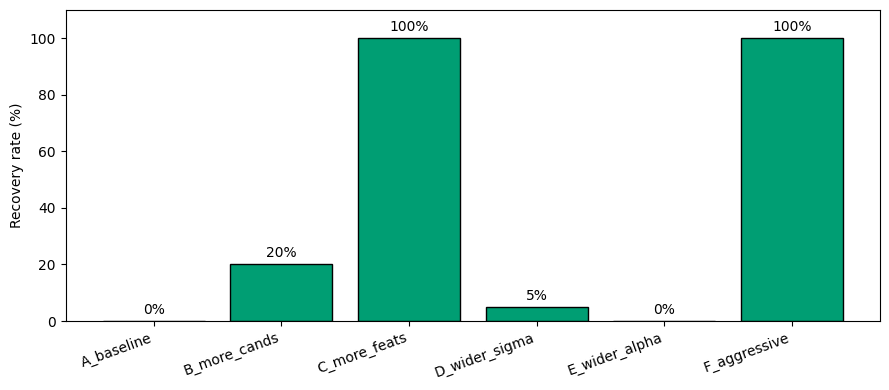

In [25]:
syn_recovery = (
    syn_sweep_df.groupby('config')['found']
    .agg(recovered='sum', total='count')
    .assign(recovery_rate=lambda d: d['recovered'] / d['total'])
    .reindex([c['name'] for c in syn_sweep_configs])
)
print(syn_recovery.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(syn_sweep_configs))
bars = ax.bar(x, syn_recovery['recovery_rate'] * 100, color='#009E73', edgecolor='k')
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.set_xticks(x)
ax.set_xticklabels([c['name'] for c in syn_sweep_configs], rotation=20, ha='right')
ax.set_ylabel('Recovery rate (%)')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("synth_recovery_rate.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_976413/667285769.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=syn_cfg_names, patch_artist=True)
/tmp/ipykernel_976413/667285769.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=syn_cfg_names, patch_artist=True)


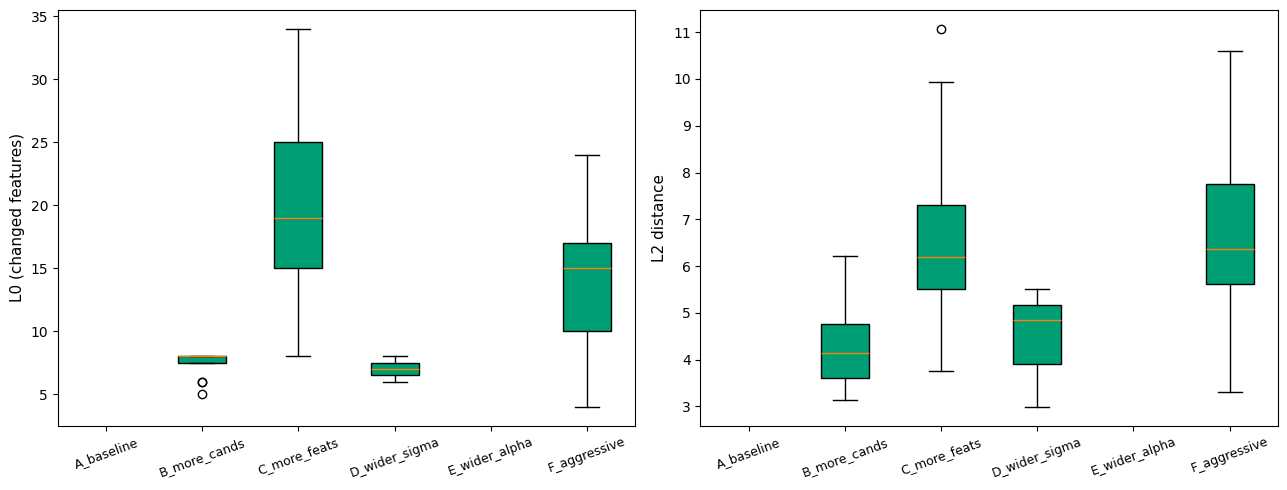

In [33]:
syn_found = syn_sweep_df[syn_sweep_df['found']].copy()
syn_cfg_names = [c['name'] for c in syn_sweep_configs]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, label in zip(axes, ['l0', 'l2'], ['L0 (changed features)', 'L2 distance']):
    data = [syn_found[syn_found['config'] == n][metric].dropna().values for n in syn_cfg_names]
    bp = ax.boxplot(data, labels=syn_cfg_names, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#009E73')
        #patch.set_alpha(0.6)
    ax.set_ylabel(label, fontsize=11)
    ax.tick_params(axis='x', rotation=20, labelsize=9)

plt.tight_layout()
plt.savefig("synth_recovery_cost.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


       config  breast_cancer / TabPFN  mc_f80_red40_inf24_s... / TabPFN
   A_baseline                      0%                                0%
 B_more_cands                     41%                               20%
 C_more_feats                    100%                              100%
D_wider_sigma                      7%                                5%
E_wider_alpha                      0%                                0%
 F_aggressive                    100%                              100%


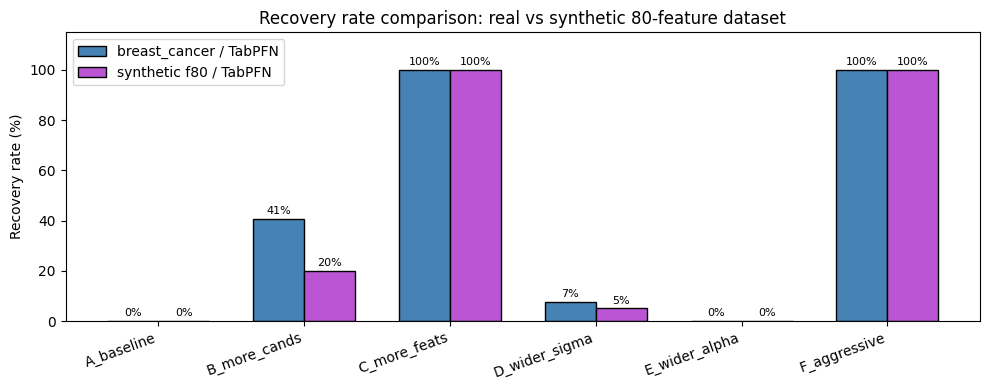

In [27]:
# Side-by-side comparison: real vs synthetic recovery rates
comp = pd.DataFrame({
    'config':    [c['name'] for c in sweep_configs],
    'breast_cancer / TabPFN': recovery['recovery_rate'].values * 100,
    f'{SYN_TARGET_DATASET[:20]}... / TabPFN': syn_recovery['recovery_rate'].values * 100,
})
print(comp.to_string(index=False, float_format=lambda x: f"{x:.0f}%"))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(sweep_configs))
w = 0.35
b1 = ax.bar(x - w/2, recovery['recovery_rate'] * 100,      w, label='breast_cancer / TabPFN', color='steelblue',    edgecolor='k')
b2 = ax.bar(x + w/2, syn_recovery['recovery_rate'] * 100,  w, label=f'synthetic f80 / TabPFN', color='mediumorchid', edgecolor='k')
ax.bar_label(b1, fmt='%.0f%%', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.0f%%', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([c['name'] for c in sweep_configs], rotation=20, ha='right')
ax.set_ylabel('Recovery rate (%)')
ax.set_title('Recovery rate comparison: real vs synthetic 80-feature dataset')
ax.set_ylim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()


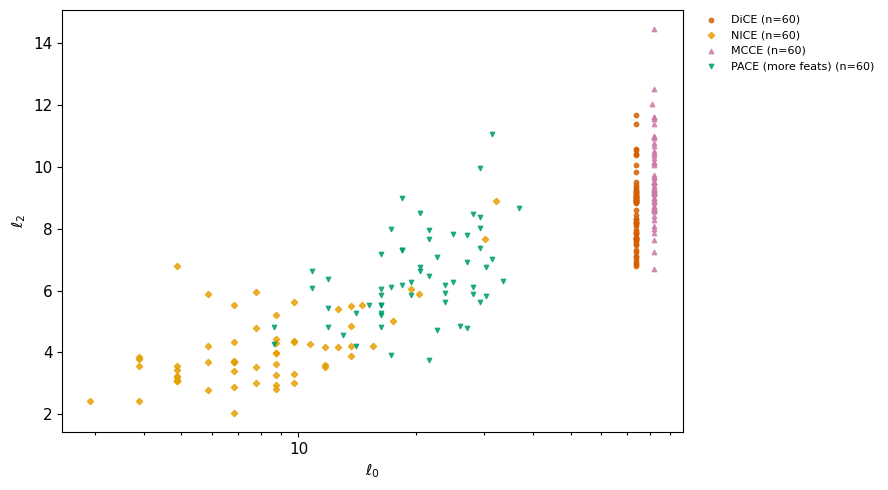

In [28]:

# ── L0 vs L2: PACE C_more_feats vs NICE / DiCE / MCCE (synthetic, originally-failed instances) ──
from matplotlib.ticker import LogLocator, FuncFormatter

syn_pace_mf = syn_sweep_df[(syn_sweep_df["config"] == "C_more_feats") & syn_sweep_df["found"]].copy()
syn_pace_mf = syn_pace_mf.assign(method="pace")
syn_target_pairs_set = set(zip(syn_pace_mf["seed"], syn_pace_mf["idx"]))

syn_other_raw = df_mock[
    (df_mock["dataset"] == SYN_TARGET_DATASET) &
    (df_mock["model"]   == SYN_TARGET_MODEL) &
    (df_mock["method"].isin(["nice_spars", "dice", "mcce"]))
].copy()
syn_other_ok = syn_other_raw[
    syn_other_raw.apply(lambda r: (r["seed"], r["idx"]) in syn_target_pairs_set, axis=1)
].dropna(subset=["l0", "l2"])

syn_plot_methods = [
    ("dice",       "DiCE",             syn_other_ok[syn_other_ok["method"] == "dice"]),
    ("nice_spars", "NICE",             syn_other_ok[syn_other_ok["method"] == "nice_spars"]),
    ("mcce",       "MCCE",             syn_other_ok[syn_other_ok["method"] == "mcce"]),
    ("pace",       "PACE (more feats)", syn_pace_mf),
]

_log_offsets   = np.linspace(-0.08, 0.08, len(syn_plot_methods))
_method_offset = {key: _log_offsets[i] for i, (key, _, __) in enumerate(syn_plot_methods)}

fig, ax = plt.subplots(figsize=(9, 5))
for key, label, sub in syn_plot_methods:
    if sub.empty:
        continue
    x_mult = np.exp(_method_offset[key])
    ax.scatter(
        sub["l0"].values * x_mult,
        sub["l2"].values,
        color=COLORS[key],
        marker=METHOD_MARKER[key],
        s=10,
        alpha=0.8,
        label=f"{label} (n={len(sub)})",
    )

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x))}"))
ax.set_xlabel(r"$\ell_0$", fontsize=11)
ax.set_ylabel(r"$\ell_2$", fontsize=11)
ax.tick_params(axis="both", which="both", width=0.8, labelsize=11)
ax.legend(
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
fig.tight_layout()
plt.savefig("synth_cond_l2_diff.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()
